In [1]:
import numpy as np
import pandas as pd

np.random.seed(123)

n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [2]:
n_class_0,n_class_1

(900, 100)

In [3]:
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

In [4]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

In [5]:
df.tail()

,feature_1,feature_2,target
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1
999,2.697490,2.013570,1


In [6]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [7]:
## upsampling
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [8]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True,
         n_samples=len(df_majority),
         random_state=42
        )

In [9]:
df_minority_upsampled.shape

(900, 3)

In [10]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1


In [11]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [12]:
# Down Sampleing

import pandas as pd

np.random.seed(123)

n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

df = pd.concat([class_0, class_1]).reset_index(drop=True)

print(df['target'].value_counts())

target
0    900
1    100
Name: count, dtype: int64


In [13]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [14]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [15]:
from sklearn.utils import resample
df_majority_upsampled=resample(df_minority,replace=True,
         n_samples=len(df_majority),
         random_state=42
        )

# SMOTE

In [16]:
!pip install imblearn



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from collections import Counter

X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, 
                           n_clusters_per_class=1, weights=[0.90], 
                           class_sep=2.0, random_state=42)



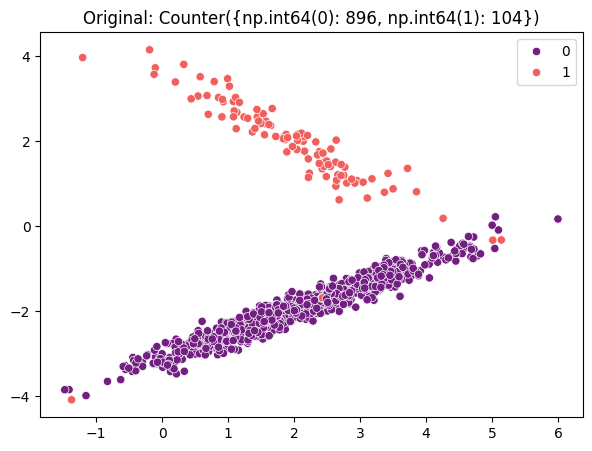

In [32]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='magma')
plt.title(f"Original: {Counter(y)}")
plt.show()

In [33]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

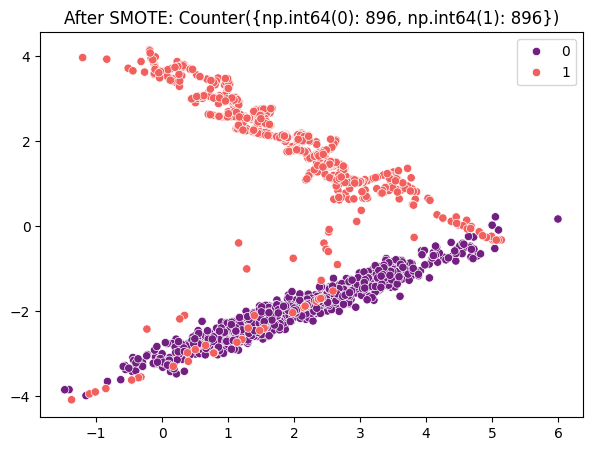

In [34]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_res[:, 0], y=X_res[:, 1], hue=y_res, palette='magma')
plt.title(f"After SMOTE: {Counter(y_res)}")
plt.show()

## Encoders

In [36]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

df = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Green', 'Red']})

encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[['Color']])

encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out())
print(encoded_df)

   Color_Blue  Color_Green  Color_Red
0         0.0          0.0        1.0
1         1.0          0.0        0.0
2         0.0          1.0        0.0
3         0.0          1.0        0.0
4         0.0          0.0        1.0


In [42]:
encoder.transform([['Blue']])

d:\Git Hub\ML-DL-NLP\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [43]:
pd.concat([df,encoded_df], axis=1)

,Color,Color_Blue,Color_Green,Color_Red
0,Red,0.0,0.0,1.0
1,Blue,1.0,0.0,0.0
2,Green,0.0,1.0,0.0
3,Green,0.0,1.0,0.0
4,Red,0.0,0.0,1.0


In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Color_Encoded'] = le.fit_transform(df['Color'])

print(df)

   Color  Color_Encoded
0    Red              2
1   Blue              0
2  Green              1
3  Green              1
4    Red              2


In [46]:
from sklearn.preprocessing import OrdinalEncoder

color_order = [['Blue', 'Green', 'Red']]

encoder = OrdinalEncoder(categories=color_order)

df['Color_Encoded'] = encoder.fit_transform(df[['Color']])


print(df)

   Color  Color_Encoded
0    Red            2.0
1   Blue            0.0
2  Green            1.0
3  Green            1.0
4    Red            2.0


In [49]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

df = pd.DataFrame({'education level' : ['High School', 'College', 'Graduate', 'Post Graduate']})

edu_order = [['High School', 'College', 'Graduate', 'Post Graduate']]

encoder = OrdinalEncoder(categories=edu_order)

df['Edu_Encoded'] = encoder.fit_transform(df[['education level']])

print(df)

  education level  Edu_Encoded
0     High School          0.0
1         College          1.0
2        Graduate          2.0
3   Post Graduate          3.0


In [61]:
# Target Guided Ordinary Encoding

import pandas as pd

df = pd.DataFrame({
    'City': ['Delhi', 'London', 'Paris', 'Delhi', 'London', 'Paris', 'Delhi'],
    'Price': [150, 700, 500, 200, 800, 550, 180]
})
df

,City,Price
0,Delhi,150
1,London,700
2,Paris,500
3,Delhi,200
4,London,800
5,Paris,550
6,Delhi,180


In [62]:
mean_price = df.groupby('City')['Price'].mean().to_dict()
mean_price

{'Delhi': 176.66666666666666, 'London': 750.0, 'Paris': 525.0}

In [ ]:
df["City Encoded"] = df["City"].map(mean_price)
df

,City,Price,City Encoded
0,Delhi,150,176.666667
1,London,700,750.000000
2,Paris,500,525.000000
3,Delhi,200,176.666667
4,London,800,750.000000
5,Paris,550,525.000000
6,Delhi,180,176.666667
